[load] source: 40,078 | qa: 7,208
[eval] single-evidence QA with gold in corpus: 2,520
[eval] corpus content loaded: 12,143
[index] doc char limit=3000 (mean raw 5,154)
[index] TF-IDF matrix: (12143, 100000), nnz=14,305,333
[B2 flat]            {'Recall@1': 0.0885, 'Recall@5': 0.229, 'Recall@10': 0.3067, 'MRR': 0.1494, 'nDCG@10': np.float64(0.1865), 'n': 2520}
[B3 anchor=0.05]       {'Recall@1': 0.0968, 'Recall@5': 0.2532, 'Recall@10': 0.3373, 'MRR': 0.1641, 'nDCG@10': np.float64(0.205), 'n': 2520}
[B3 anchor=0.1 ]       {'Recall@1': 0.1036, 'Recall@5': 0.2675, 'Recall@10': 0.3552, 'MRR': 0.1744, 'nDCG@10': np.float64(0.217), 'n': 2520}
[B3 anchor=0.2 ]       {'Recall@1': 0.1087, 'Recall@5': 0.279, 'Recall@10': 0.371, 'MRR': 0.1835, 'nDCG@10': np.float64(0.2278), 'n': 2520}
[by group] (B3 anchor=0.2)
 country   category    n  B2_Recall@10  B3_Recall@10  B2_MRR  B3_MRR
Malaysia Legal case  179        0.1229        0.2235  0.0414  0.0885
Malaysia Regulation 1080        0.2370        0.31

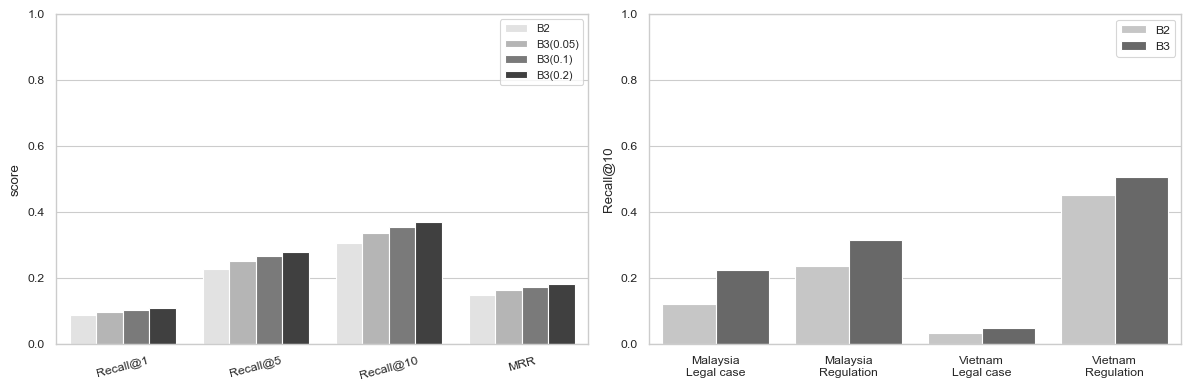

[RQ2] best B3 anchor=0.2: Recall@10 0.307 -> 0.371 (+0.064), MRR 0.149 -> 0.183 (+0.034)

[done] notebook 04 complete.


In [1]:
# ============================================================================
# Notebook 04 · Retrieval & Linking Evaluation — B2 (flat) vs B3 (ontology)
# ----------------------------------------------------------------------------
# Uses QA source_id (answer<->evidence links) as ground truth to measure
# retrieval quality, and compares two baselines:
#   B2 = flat char n-gram TF-IDF cosine ranking (no structure)
#   B3 = ontology-anchored re-ranking: B2 score + a bonus for corpus docs in the
#        SAME Jurisdiction / ESGTopic as the query (from the nb02 graph signals)
# The B3 > B2 gain is the quantitative evidence for RQ2.
#
# Input : data/interim/source.parquet, data/interim/qa.parquet, raw zips
# Output: results/tables/table04_*.csv, results/figures/fig04_* (png, pdf)
#
# Reproducibility:
#   - Retriever is char n-gram TF-IDF (no external model/internet) -> identical
#     results on any machine.
#   - JOIN on doc_id (= data.id); QA.source_id points to data.id, not metadata.id.
#   - The anchor uses only the query QA's own country/esg (NOT the gold label),
#     so it does not leak the answer.
#   - Long docs truncated to a head window to bound memory/vocabulary.
# All outputs English-only; figures grayscale, no titles, dpi=600.
# ============================================================================

import os, re, json, random, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------------------------------------------------------
# 0. Paths, seed, figure styling
# ----------------------------------------------------------------------------
PROJECT_ROOT  = Path.cwd().parent
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR   = PROJECT_ROOT / "data" / "interim"
FIGURES_DIR   = PROJECT_ROOT / "results" / "figures"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"
for _d in (FIGURES_DIR, TABLES_DIR):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

matplotlib.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="paper"); sns.set_palette("Greys_r")
FIG_DPI = 600; GREY_DARK, GREY_MID, GREY_LIGHT = "#333333", "#777777", "#BBBBBB"

def save_fig(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(FIGURES_DIR / f"{stem}.{ext}", dpi=FIG_DPI, bbox_inches="tight")
    print(f"[save] figure {stem} (png, pdf)")

# ----------------------------------------------------------------------------
# 1. On-demand content loader (memory-safe; Regulation=01 + Legal-case=03 zips)
# ----------------------------------------------------------------------------
def _find_source_zip(country_ko, catcode):
    for p in sorted(RAW_DIR.glob("*.zip")):
        if country_ko in p.name and re.search(rf"_{catcode}[._ ]", p.name):
            return p
    return None

def load_content_for_ids(ids, catcodes=("01", "03")):
    """Return DataFrame[id, doc_id, content_ko] for requested metadata ids."""
    ids = set(ids); rows = []
    for country_ko in ("베트남", "말레이시아"):
        for cc in catcodes:
            zp = _find_source_zip(country_ko, cc)
            if zp is None:
                continue
            with zipfile.ZipFile(zp) as zf:
                for name in sorted(zf.namelist()):
                    if not name.endswith(".json"):
                        continue
                    d = json.load(zf.open(name))
                    _id = d.get("metadata", {}).get("id", "")
                    if _id not in ids:
                        continue
                    data = d.get("data", {}) or {}
                    c = data.get("content", {}) or {}
                    rows.append({"id": _id, "doc_id": data.get("id", ""),
                                 "content_ko": c.get("ko", "") or ""})
    return pd.DataFrame(rows).sort_values("doc_id").reset_index(drop=True)

# ----------------------------------------------------------------------------
# 2. Build evaluation set from QA (single-evidence, Regulation/Legal-case)
# ----------------------------------------------------------------------------
source = pd.read_parquet(INTERIM_DIR / "source.parquet")
qa = pd.read_parquet(INTERIM_DIR / "qa.parquet")
print(f"[load] source: {len(source):,} | qa: {len(qa):,}")

qa = qa.copy()
qa["source_ids"] = qa["source_id"].apply(json.loads)
qa["n_src"] = qa["source_ids"].apply(len)
qa_eval = qa[(qa.n_src == 1) & (qa.category.isin(["Regulation", "Legal case"]))].copy()
qa_eval["gold_id"] = qa_eval["source_ids"].apply(lambda x: x[0])   # a doc_id

# Corpus = Regulation + Legal-case docs; carry country/esg as anchor signals
corpus_meta = source[source.category.isin(["Regulation", "Legal case"])][
    ["id", "doc_id", "country", "esg", "category"]]
corpus_docids = set(corpus_meta["doc_id"])
qa_eval = qa_eval[qa_eval.gold_id.isin(corpus_docids)].reset_index(drop=True)
print(f"[eval] single-evidence QA with gold in corpus: {len(qa_eval):,}")
assert len(qa_eval) > 0, "join failed: check doc_id mapping"

# Load content only for corpus docs (memory-safe), attach doc_id + anchors
content = load_content_for_ids(set(corpus_meta["id"]))
content = content.merge(corpus_meta[["id", "country", "esg"]], on="id", how="left")
print(f"[eval] corpus content loaded: {len(content):,}")

# ----------------------------------------------------------------------------
# 3. Build TF-IDF index (B2 core)
# ----------------------------------------------------------------------------
def first_user_turn(turns_json):
    for t in json.loads(turns_json):
        if t.get("role") == "user":
            return t.get("content", "")
    return ""
qa_eval["query"] = qa_eval["qa_turns"].apply(first_user_turn)

corpus = content.sort_values("doc_id").reset_index(drop=True)
doc_ids     = np.array(corpus["doc_id"].tolist())
doc_country = corpus["country"].values
doc_esg     = corpus["esg"].values

DOC_CHAR_LIMIT = 3000
doc_text = corpus["content_ko"].str.slice(0, DOC_CHAR_LIMIT).tolist()
print(f"[index] doc char limit={DOC_CHAR_LIMIT} "
      f"(mean raw {int(corpus['content_ko'].str.len().mean()):,})")

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 4),
                      min_df=3, max_features=100_000, dtype=np.float32)
doc_mat = vec.fit_transform(doc_text)
print(f"[index] TF-IDF matrix: {doc_mat.shape}, nnz={doc_mat.nnz:,}")

# ----------------------------------------------------------------------------
# 4. Unified evaluator: anchor=0 -> B2; anchor>0 -> B3 (ontology-anchored)
#    B3 score = cosine + anchor * (0.5*[same country] + 0.5*[same ESG topic])
#    The anchor uses the QUERY's country/esg (from QA), never the gold label.
# ----------------------------------------------------------------------------
def evaluate(queries, golds, q_country, q_esg, anchor=0.0,
             k_list=(1, 5, 10), batch=256):
    maxk = max(k_list); recall = {k: 0 for k in k_list}; rr = ndcg = 0.0
    n = len(golds)
    for s in range(0, n, batch):
        qc = queries[s:s+batch]; gc = golds[s:s+batch]
        cc = q_country[s:s+batch]; ce = q_esg[s:s+batch]
        qm = vec.transform(qc)
        sims = cosine_similarity(qm, doc_mat)              # (b, Ndoc)
        if anchor > 0:
            for i in range(len(qc)):
                bonus = anchor * ((doc_country == cc[i]).astype(np.float32) * 0.5
                                  + (doc_esg == ce[i]).astype(np.float32) * 0.5)
                sims[i] = sims[i] + bonus
        part = np.argpartition(-sims, kth=min(maxk, sims.shape[1]-1), axis=1)[:, :maxk]
        for i, gid in enumerate(gc):
            cand = part[i]; cand = cand[np.argsort(-sims[i, cand])]
            top = doc_ids[cand]; hit = np.where(top == gid)[0]
            if len(hit):
                pos = int(hit[0]); rr += 1/(pos+1); ndcg += 1/np.log2(pos+2)
                for k in k_list:
                    if pos < k: recall[k] += 1
    out = {f"Recall@{k}": round(recall[k]/n, 4) for k in k_list}
    out["MRR"] = round(rr/n, 4); out[f"nDCG@{maxk}"] = round(ndcg/n, 4); out["n"] = n
    return out

Q  = qa_eval["query"].tolist()
G  = qa_eval["gold_id"].tolist()
QC = qa_eval["country"].values
QE = qa_eval["esg"].values

# B2 + B3 anchor sweep
ANCHORS = [0.05, 0.10, 0.20]
res_b2 = evaluate(Q, G, QC, QE, anchor=0.0)
print("[B2 flat]           ", res_b2)
res_b3 = {a: evaluate(Q, G, QC, QE, anchor=a) for a in ANCHORS}
for a in ANCHORS:
    print(f"[B3 anchor={a:<4}]      ", res_b3[a])

# ----------------------------------------------------------------------------
# 5. By country x category (B2 vs best B3)
# ----------------------------------------------------------------------------
best_a = max(ANCHORS, key=lambda a: res_b3[a]["Recall@10"])
rows = []
for (ctry, cat), grp in qa_eval.groupby(["country", "category"]):
    if len(grp) == 0:
        continue
    gq, gg = grp["query"].tolist(), grp["gold_id"].tolist()
    gc, ge = grp["country"].values, grp["esg"].values
    r2 = evaluate(gq, gg, gc, ge, anchor=0.0)
    r3 = evaluate(gq, gg, gc, ge, anchor=best_a)
    rows.append({"country": ctry, "category": cat, "n": r2["n"],
                 "B2_Recall@10": r2["Recall@10"], "B3_Recall@10": r3["Recall@10"],
                 "B2_MRR": r2["MRR"], "B3_MRR": r3["MRR"]})
by_group = pd.DataFrame(rows)
print(f"[by group] (B3 anchor={best_a})")
print(by_group.to_string(index=False))

# ----------------------------------------------------------------------------
# 6. Save tables + figures
# ----------------------------------------------------------------------------
overall_rows = [{"method": "B2_flat", "anchor": 0.0, **res_b2}]
for a in ANCHORS:
    overall_rows.append({"method": "B3_anchored", "anchor": a, **res_b3[a]})
overall = pd.DataFrame(overall_rows)
overall.to_csv(TABLES_DIR / "table04_retrieval.csv", index=False, encoding="utf-8-sig")
by_group.to_csv(TABLES_DIR / "table04b_retrieval_by_group.csv",
                index=False, encoding="utf-8-sig")

# Figure 04a: B2 vs B3 anchor sweep on the main metrics
metrics = ["Recall@1", "Recall@5", "Recall@10", "MRR"]
plot_rows = [{"method": "B2", **{m: res_b2[m] for m in metrics}}]
for a in ANCHORS:
    plot_rows.append({"method": f"B3({a})", **{m: res_b3[a][m] for m in metrics}})
plot_df = pd.DataFrame(plot_rows).melt(id_vars="method", var_name="metric", value_name="score")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=plot_df, x="metric", y="score", hue="method",
            palette="Greys", ax=axes[0])
axes[0].set_xlabel(""); axes[0].set_ylabel("score"); axes[0].set_ylim(0, 1)
axes[0].legend(title="", fontsize=8); axes[0].tick_params(axis="x", rotation=15)

# Figure 04b: B2 vs best-B3 Recall@10 by group
bg = by_group.copy()
bg["group"] = bg["country"] + "\n" + bg["category"]
bg_long = bg.melt(id_vars="group", value_vars=["B2_Recall@10", "B3_Recall@10"],
                  var_name="method", value_name="Recall@10")
bg_long["method"] = bg_long["method"].str.replace("_Recall@10", "")
sns.barplot(data=bg_long, x="group", y="Recall@10", hue="method",
            palette="Greys", ax=axes[1])
axes[1].set_xlabel(""); axes[1].set_ylabel("Recall@10"); axes[1].set_ylim(0, 1)
axes[1].legend(title="")
fig.tight_layout(); save_fig(fig, "fig04_retrieval"); plt.show()

# Console summary of the RQ2 gain
gain_r10 = res_b3[best_a]["Recall@10"] - res_b2["Recall@10"]
gain_mrr = res_b3[best_a]["MRR"] - res_b2["MRR"]
print(f"[RQ2] best B3 anchor={best_a}: "
      f"Recall@10 {res_b2['Recall@10']:.3f} -> {res_b3[best_a]['Recall@10']:.3f} "
      f"(+{gain_r10:.3f}), MRR {res_b2['MRR']:.3f} -> {res_b3[best_a]['MRR']:.3f} "
      f"(+{gain_mrr:.3f})")
print("\n[done] notebook 04 complete.")